# 従業員離職率分析

## 分析目的

IBM HR Analytics Employee Attrition & Performanceデータセットを使用し、従業員の離職にどのような特徴が見られるのかを分析します。

年齢、勤続年数、職位、職種、残業、仕事満足度などの観点から離職率を比較し、離職率が高い従業員グループの特徴を確認します。

なお、本分析では各変数と離職の関連性を確認するものであり、因果関係を示すものではありません。

## 1. データの読み込み

In [1]:
# Googleドライブのマウント
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### データセットの読み込み

Google Driveに保存したIBM HR Analytics Employee Attrition & Performanceデータセットをpandasで読み込みます。

In [2]:
# CSVファイルを読み込む
import pandas as pd
employee_df = pd.read_csv("/content/drive/MyDrive/employee-analytics-portfolio/data/WA_Fn-UseC_-HR-Employee-Attrition.csv")
employee_df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## 2. データの基本情報確認

データ件数、カラム構成、データ型、欠損値の有無を確認します。

In [3]:
# データの行数および列数を確認する
employee_df.shape

(1470, 35)

データは1,470行、35列で構成されています。

In [4]:
# 35項目を確認する
for i, column in enumerate(employee_df.columns):
  print(i, column)

0 Age
1 Attrition
2 BusinessTravel
3 DailyRate
4 Department
5 DistanceFromHome
6 Education
7 EducationField
8 EmployeeCount
9 EmployeeNumber
10 EnvironmentSatisfaction
11 Gender
12 HourlyRate
13 JobInvolvement
14 JobLevel
15 JobRole
16 JobSatisfaction
17 MaritalStatus
18 MonthlyIncome
19 MonthlyRate
20 NumCompaniesWorked
21 Over18
22 OverTime
23 PercentSalaryHike
24 PerformanceRating
25 RelationshipSatisfaction
26 StandardHours
27 StockOptionLevel
28 TotalWorkingYears
29 TrainingTimesLastYear
30 WorkLifeBalance
31 YearsAtCompany
32 YearsInCurrentRole
33 YearsSinceLastPromotion
34 YearsWithCurrManager


In [5]:
# データ型と欠損値を確認
employee_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [6]:
# 欠損値を確認
employee_df.isnull().sum().sum()

np.int64(0)

欠損値はありませんでした。

## 3. 離職状況の確認

まず、データ全体における在籍者と退職者の人数および割合を確認します。

In [7]:
# 退職者数を確認する
employee_df["Attrition"].value_counts()

,count
Attrition,
No,1233
Yes,237


In [8]:
# 退職割合を確認する
employee_df["Attrition"].value_counts(normalize=True).mul(100).round(1)

,proportion
Attrition,
No,83.9
Yes,16.1


### 確認結果

全1,470人のうち、在籍者（No）は1,233人、退職者（Yes）は237人でした。

全体の離職率は **16.1%** です。

## 4. 年齢・勤続年数の分析

退職者と在籍者の年齢を比較し、年代によって離職率に違いがあるか確認します。
また、退職者の勤続年数を年代別に確認し、若年層の離職時期について分析します。

In [9]:
# 「退職した人」と「退職していない人」で年齢に違いがあるのか確認する
employee_df.groupby("Attrition")["Age"].agg(["count", "mean", "median", "min", "max"])

,count,mean,median,min,max
Attrition,,,,,
No,1233,37.561233,36.0,18,60
Yes,237,33.607595,32.0,18,58


### 年齢の比較

退職者の平均年齢は33.6歳、在籍者は37.6歳であり、
退職者は在籍者と比較して若い傾向が確認されました。

そこで、年代別に離職率を確認します。

### 年代別の離職率

年代別に離職率を比較するため、Ageを20代～60代に分類します。

In [10]:
# 年代別にラベリングする
employee_df["AgeGroup"] = pd.cut(
    employee_df["Age"],
    bins = [0, 29, 39, 49, 59, 100],
    labels = ["20代", "30代", "40代", "50代", "60代"]
)

In [11]:
age_attrition = pd.crosstab(
    employee_df["AgeGroup"],
    employee_df["Attrition"],
    normalize="index"
) * 100

age_attrition

Attrition,No,Yes
AgeGroup,,
20代,72.085890,27.914110
30代,85.691318,14.308682
40代,90.257880,9.742120
50代,86.309524,13.690476
60代,100.000000,0.000000


年代別では、**20代の離職率が27.9%と最も高い**結果となりました。

一方、60代の離職率は0%ですが、該当者が少ない可能性があるため、
年代別の従業員数も確認します。

In [12]:
# 年代別の人数を確認する
employee_df["AgeGroup"].value_counts().sort_index()

,count
AgeGroup,
20代,326
30代,622
40代,349
50代,168
60代,5


60代は5人のみであり、他の年代と比較してサンプル数が非常に少ないため、
離職率0%については参考値として扱います。

In [13]:
# 退職者の勤続年数を確認する
employee_df.groupby("Attrition")["YearsAtCompany"].agg(
    ["count", "mean", "median", "min", "max"]
)

,count,mean,median,min,max
Attrition,,,,,
No,1233,7.369019,6.0,0,37
Yes,237,5.130802,3.0,0,40


In [14]:
# 退職者に絞って年代別の勤続年数を確認する
employee_df[employee_df["Attrition"] == "Yes"].groupby("AgeGroup")["YearsAtCompany"].agg(
    ["count", "mean", "median", "min", "max"]
)

/tmp/ipykernel_21984/4032860081.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  employee_df[employee_df["Attrition"] == "Yes"].groupby("AgeGroup")["YearsAtCompany"].agg(


,count,mean,median,min,max
AgeGroup,,,,,
20代,91,2.824176,2.0,0.0,11.0
30代,89,5.056180,4.0,0.0,18.0
40代,34,7.676471,6.0,1.0,24.0
50代,23,10.782609,6.0,0.0,40.0
60代,0,NaN,NaN,NaN,NaN


### 退職者の年代別勤続年数

退職者の勤続年数を年代別に確認すると、
20代の平均勤続年数は2.8年、中央値2年、
30代では平均5.1年、中央値4年でした。

若年層の退職者では、比較的勤続年数が短い傾向が確認されました。

一方、50代の退職者は平均勤続年数10.8年に対して中央値は6年でした。
最大値が40年であることから、一部の長期勤続者が平均値を押し上げている可能性があります。

## 5. JobLevelの分析

年代別では20代の離職率が最も高いことが確認されました。

次に、職位（JobLevel）によって離職率に違いがあるかを確認します。
また、年齢とJobLevelの関係も確認し、20代の高い離職率について職位構成の影響も考えます。

In [15]:
# 職位ごとの退職者数を確認する
employee_df.groupby("JobLevel")["Attrition"].value_counts()

JobLevel  Attrition
1         No           400
          Yes          143
2         No           482
          Yes           52
3         No           186
          Yes           32
4         No           101
          Yes            5
5         No            64
          Yes            5
Name: count, dtype: int64

In [16]:
# 職位ごとの離職率を確認する
joblevel_attrition = pd.crosstab(
    employee_df["JobLevel"],
    employee_df["Attrition"],
    normalize="index"
) * 100

joblevel_attrition

Attrition,No,Yes
JobLevel,,
1,73.664825,26.335175
2,90.262172,9.737828
3,85.321101,14.678899
4,95.283019,4.716981
5,92.753623,7.246377


### JobLevel別の離職率

JobLevel別では、**JobLevel 1の離職率が26.3%と最も高い**結果となりました。

また、退職者237人のうちJobLevel 1は143人で、退職者全体の約60.3%を占めています。  
一方、JobLevel 2～5の離職率は職位が高くなるにつれて一貫して低下しているわけではありません。
そのため、「JobLevelが低いほど離職率が高い」と単純に結論づけるのではなく、
特にJobLevel 1で高い離職率が確認されたと捉えます。

### 年代 × JobLevelの分析

20代とJobLevel 1の両方で高い離職率が確認されました。

そこで、20代の高い離職率について年齢だけでなくJobLevelの構成も関係している可能性を考え、
年代とJobLevelを組み合わせて確認します。

In [17]:
# 年代および職位ごとに離職率を調べる
age_joblevel_attrition = pd.crosstab(
    [employee_df["AgeGroup"], employee_df["JobLevel"]],
    employee_df["Attrition"],
    normalize="index"
) * 100

age_joblevel_attrition

Attrition                  No        Yes
AgeGroup JobLevel                       
20代      1          64.888889  35.111111
         2          90.804598   9.195402
         3          69.230769  30.769231
         4         100.000000   0.000000
30代      1          79.166667  20.833333
         2          89.122807  10.877193
         3          88.888889  11.111111
         4          90.000000  10.000000
         5         100.000000   0.000000
40代      1          83.783784  16.216216
         2          93.700787   6.299213
         3          85.714286  14.285714
         4          93.750000   6.250000
         5          94.594595   5.405405
50代      1          75.000000  25.000000
         2          84.848485  15.151515
         3          78.125000  21.875000
         4          97.872340   2.127660
         5          89.285714  10.714286
60代      2         100.000000   0.000000
         3         100.000000   0.000000
         5         100.000000   0.000000

JobLevel 1では複数の年代で比較的高い離職率が見られました。

一方、JobLevel 2～5を含めると年代によって離職率の順位は異なっており、
JobLevelと離職率の関係は単純な直線的関係ではないことが確認されました。

In [18]:
# 年代ごとに職位の人数構成を調べる
age_joblevel_count = pd.crosstab(
    employee_df["AgeGroup"],
    employee_df["JobLevel"]
)

age_joblevel_count

JobLevel,1,2,3,4,5
AgeGroup,,,,,
20代,225,87,13,1,0
30代,216,285,108,10,3
40代,74,127,63,48,37
50代,28,33,32,47,28
60代,0,2,2,0,1


20代326人のうちJobLevel 1は225人で、約69.0%を占めていました。

20代ではJobLevel 1の割合が高いため、
20代の高い離職率については年齢だけでなくJobLevelの構成も考慮する必要があります。

この結果だけでは、年齢とJobLevelのどちらが離職に影響しているのかを切り分けることはできません。

In [19]:
# 職位別に勤続年数を比較する
employee_df.groupby("JobLevel")["YearsAtCompany"].agg(
    ["count", "mean", "median", "min", "max"]
)

,count,mean,median,min,max
JobLevel,,,,,
1,543,3.931860,3.0,0,20
2,534,6.752809,6.0,0,20
3,218,9.380734,9.0,0,40
4,106,13.886792,12.5,1,37
5,69,15.130435,18.0,0,36


In [20]:
# 退職者だけに絞った職位別の勤続年数を比較する
employee_df[employee_df["Attrition"] == "Yes"].groupby("JobLevel")["YearsAtCompany"].agg(
    ["count", "mean", "median", "min", "max"]
)

,count,mean,median,min,max
JobLevel,,,,,
1,143,3.083916,2.0,0,17
2,52,5.250000,5.0,0,15
3,32,9.562500,8.5,0,40
4,5,16.400000,19.0,1,23
5,5,22.800000,24.0,5,32


### JobLevelと勤続年数

退職者のJobLevel別勤続年数を見ると、
JobLevel 1の退職者は平均3.1年、中央値2年であり、
比較的勤続年数が短いことが確認されました。

また、JobLevelが高いグループほど勤続年数が長い傾向が見られます。

ただし、JobLevelは勤続年数と関係している可能性があるため、
JobLevel単独の影響として解釈することには注意が必要です。

###

## 6. MonthlyIncomeの分析

退職者と在籍者で月収（MonthlyIncome）に違いがあるかを確認します。

また、JobLevel 1に退職者が多いことから、JobLevelの構成が月収の差に関係している可能性も考慮して分析します。

In [21]:
# 退職者および在籍者の月収を比較する
employee_df.groupby("Attrition")["MonthlyIncome"].agg(
    ["count", "mean", "median", "min", "max"]
)

,count,mean,median,min,max
Attrition,,,,,
No,1233,6832.739659,5204.0,1051,19999
Yes,237,4787.092827,3202.0,1009,19859


### 退職者と在籍者の月収比較

退職者の平均MonthlyIncomeは4,787.1、在籍者は6,832.7であり、
退職者の方が平均で約2,045.6低い結果となりました。

ただし、これまでの分析では退職者の約60.3%がJobLevel 1であることが確認されています。

MonthlyIncomeはJobLevelによって異なる可能性があるため、
この差をそのまま「月収が低い従業員ほど離職しやすい」と解釈することはできません。

そこで、JobLevel 1に限定してMonthlyIncomeを比較します。

In [22]:
# JobLevel1に限定して比較する
employee_df[employee_df["JobLevel"] == 1].groupby("Attrition")["MonthlyIncome"].agg(
    ["count", "mean", "median", "min", "max"]
)

,count,mean,median,min,max
Attrition,,,,,
No,400,2854.407500,2719.0,1051,4968
Yes,143,2598.125874,2437.0,1009,4963


### JobLevel 1に限定した月収比較

JobLevel 1に限定すると、
在籍者の平均MonthlyIncomeは2,854.4、
退職者は2,598.1となり、その差は約256.3でした。

全従業員で比較した場合の差は約2,045.6でしたが、
JobLevel 1に限定すると差が大きく縮小しました。

このことから、退職者と在籍者のMonthlyIncomeの差には、
退職者がJobLevel 1に多く分布していることが関係している可能性があります。

したがって、今回の結果だけから
「MonthlyIncomeが低いことが離職につながっている」と判断することはできません。

## 7. 残業（OverTime）の分析

残業（OverTime）の有無によって離職率に違いがあるかを確認します。

さらに、これまでの分析で離職率が高かった年齢やJobLevelと組み合わせ、
特定の従業員グループで離職率が高くなっていないかを確認します。

In [23]:
# 残業の有無による退職者の構成を比較する
pd.crosstab(
    employee_df["OverTime"],
    employee_df["Attrition"]
)

Attrition,No,Yes
OverTime,,
No,944,110
Yes,289,127


In [24]:
overtime_attrition = pd.crosstab(
    employee_df["OverTime"],
    employee_df["Attrition"],
    normalize="index"
) * 100

overtime_attrition

Attrition,No,Yes
OverTime,,
No,89.563567,10.436433
Yes,69.471154,30.528846


### OverTime別の離職率

残業なしの従業員の離職率は10.4%だったのに対し、
残業ありの従業員では30.5%でした。

残業ありの従業員の離職率は、残業なしと比較して約2.9倍となっています。

この結果からOverTimeと離職の間に関連が見られますが、
この時点では残業が離職の直接的な原因であるとは判断できません。

そこで、JobLevelとOverTimeを組み合わせて離職率を確認します。

In [25]:
# 職位および在籍有無ごとの離職率を調べる
joblevel_overtime_attrition = pd.crosstab(
    [employee_df["JobLevel"], employee_df["OverTime"]],
    employee_df["Attrition"],
    normalize="index"
) * 100

joblevel_overtime_attrition

Attrition                 No        Yes
JobLevel OverTime                      
1        No        84.237726  15.762274
         Yes       47.435897  52.564103
2        No        93.298969   6.701031
         Yes       82.191781  17.808219
3        No        87.741935  12.258065
         Yes       79.365079  20.634921
4        No        97.260274   2.739726
         Yes       90.909091   9.090909
5        No        96.078431   3.921569
         Yes       83.333333  16.666667

### JobLevel × OverTime

すべてのJobLevelで、残業ありのグループは残業なしのグループより
離職率が高い結果となりました。

特にJobLevel 1では、残業なしの離職率が15.8%だったのに対し、
残業ありでは52.6%となっています。

JobLevel 1はもともと離職率が高いグループでしたが、
残業の有無によってさらに大きな差が見られました。

そこで、これまで離職率が高かった20代も加えて確認します。

In [26]:
# 職位と残業有無の構成を比較する
joblevel_overtime_count = pd.crosstab(
    employee_df["JobLevel"],
    employee_df["OverTime"]
)

joblevel_overtime_count

OverTime,No,Yes
JobLevel,,
1,387,156
2,388,146
3,155,63
4,73,33
5,51,18


In [27]:
# 退職状況と残業有無を比較する
joblevel_overtime_attriton_count = pd.crosstab(
    [employee_df["JobLevel"],employee_df["OverTime"]],
    employee_df["Attrition"]
)

joblevel_overtime_attriton_count

Attrition           No  Yes
JobLevel OverTime          
1        No        326   61
         Yes        74   82
2        No        362   26
         Yes       120   26
3        No        136   19
         Yes        50   13
4        No         71    2
         Yes        30    3
5        No         49    2
         Yes        15    3

JobLevel 1 × 残業ありのグループは156人で、
そのうち82人が退職していました。

そのため、52.6%という離職率は極端に少ないサンプルから算出された値ではありません。

### 年代 × JobLevel × OverTime

これまでの分析では、20代、JobLevel 1、残業ありのグループで
それぞれ比較的高い離職率が確認されました。

そこで、この3つの条件を組み合わせて離職率を確認します。

In [28]:
# 年代の情報を追加して退職率を比較する
age_joblevel_overtime = pd.crosstab(
    [
        employee_df["AgeGroup"],
        employee_df["JobLevel"],
        employee_df["OverTime"]
    ],
    employee_df["Attrition"],
    normalize="index"
) * 100

age_joblevel_overtime

Attrition                           No        Yes
AgeGroup JobLevel OverTime                       
20代      1        No         78.481013  21.518987
                  Yes        32.835821  67.164179
         2        No         93.548387   6.451613
                  Yes        84.000000  16.000000
         3        No         72.727273  27.272727
                  Yes        50.000000  50.000000
         4        No        100.000000   0.000000
30代      1        No         86.875000  13.125000
                  Yes        57.142857  42.857143
         2        No         93.364929   6.635071
                  Yes        77.027027  22.972973
         3        No         91.025641   8.974359
                  Yes        83.333333  16.666667
         4        No         87.500000  12.500000
                  Yes       100.000000   0.000000
         5        No        100.000000   0.000000
                  Yes       100.000000   0.000000
40代      1        No         93.877551   6.122449
                  Yes        64.000000  36.000000
         2        No         94.565217   5.434783
                  Yes        91.428571   8.571429
         3        No         85.365854  14.634146
                  Yes        86.363636  13.636364
         4        No         97.058824   2.941176
                  Yes        85.714286  14.285714
         5        No         96.774194   3.225806
                  Yes        83.333333  16.666667
50代      1        No         85.000000  15.000000
                  Yes        50.000000  50.000000
         2        No         86.363636  13.636364
                  Yes        81.818182  18.181818
         3        No         86.956522  13.043478
                  Yes        55.555556  44.444444
         4        No        100.000000   0.000000
                  Yes        94.117647   5.882353
         5        No         94.117647   5.882353
                  Yes        81.818182  18.181818
60代      2        No        100.000000   0.000000
                  Yes       100.000000   0.000000
         3        No        100.000000   0.000000
         5        No        100.000000   0.000000

In [29]:
# 年代を追加して退職者数を比較する
age_joblevel_overtime_count = pd.crosstab(
    [employee_df["AgeGroup"],
     employee_df["JobLevel"],
     employee_df["OverTime"]
    ],
    employee_df["Attrition"]
)

age_joblevel_overtime_count

Attrition                    No  Yes
AgeGroup JobLevel OverTime          
20代      1        No        124   34
                  Yes        22   45
         2        No         58    4
                  Yes        21    4
         3        No          8    3
                  Yes         1    1
         4        No          1    0
30代      1        No        139   21
                  Yes        32   24
         2        No        197   14
                  Yes        57   17
         3        No         71    7
                  Yes        25    5
         4        No          7    1
                  Yes         2    0
         5        No          2    0
                  Yes         1    0
40代      1        No         46    3
                  Yes        16    9
         2        No         87    5
                  Yes        32    3
         3        No         35    6
                  Yes        19    3
         4        No         33    1
                  Yes        12    2
         5        No         30    1
                  Yes         5    1
50代      1        No         17    3
                  Yes         4    4
         2        No         19    3
                  Yes         9    2
         3        No         20    3
                  Yes         5    4
         4        No         30    0
                  Yes        16    1
         5        No         16    1
                  Yes         9    2
60代      2        No          1    0
                  Yes         1    0
         3        No          2    0
         5        No          1    0

### 20代 × JobLevel 1 × OverTime

20代 × JobLevel 1の従業員について残業の有無で比較すると、

- 残業なし：158人中34人が退職（離職率21.5%）
- 残業あり：67人中45人が退職（離職率67.2%）

となりました。

同じ20代・JobLevel 1でも、残業ありのグループでは
残業なしと比較して離職率が約45.6ポイント高い結果となっています。

今回確認したグループの中でも、
**20代 × JobLevel 1 × 残業ありは特に高い離職率を示すグループ**として確認されました。

ただし、この結果は3つの条件と離職との関連性を示すものであり、
残業などが離職の直接的な原因であるとは断定できません。

### ここまでの分析で確認された特徴

ここまでの分析から、以下の特徴が確認されました。

- 20代の離職率は27.9%と年代別で最も高い
- JobLevel 1の離職率は26.3%で、退職者全体の約60.3%を占める
- JobLevel 1の退職者は平均勤続年数3.1年、中央値2年と比較的勤続年数が短い
- 残業ありの従業員の離職率は30.5%で、残業なしの約2.9倍
- 20代 × JobLevel 1 × 残業ありでは、67人中45人が退職し、離職率は67.2%

これらの結果から、特に若年層・JobLevel 1・残業ありの組み合わせに注目し、
さらに職種（JobRole）などの特徴について分析します。

## 8. JobRoleの分析

これまでの分析では、JobLevel 1や残業ありの従業員で高い離職率が確認されました。

次に、職種（JobRole）によって離職率に違いがあるかを確認します。
また、離職率が高い職種について、JobLevelの構成や残業の有無も確認します。

In [30]:
# 職種ごとの退職者数を確認する
pd.crosstab(
    employee_df["JobRole"],
    employee_df["Attrition"]
)

Attrition,No,Yes
JobRole,,
Healthcare Representative,122,9
Human Resources,40,12
Laboratory Technician,197,62
Manager,97,5
Manufacturing Director,135,10
Research Director,78,2
Research Scientist,245,47
Sales Executive,269,57
Sales Representative,50,33


In [31]:
# 職種ごとの離職率を比較する
jobrole_attrition = pd.crosstab(
    employee_df["JobRole"],
    employee_df["Attrition"],
    normalize="index"
) * 100

jobrole_attrition

Attrition,No,Yes
JobRole,,
Healthcare Representative,93.129771,6.870229
Human Resources,76.923077,23.076923
Laboratory Technician,76.061776,23.938224
Manager,95.098039,4.901961
Manufacturing Director,93.103448,6.896552
Research Director,97.500000,2.500000
Research Scientist,83.904110,16.095890
Sales Executive,82.515337,17.484663
Sales Representative,60.240964,39.759036


### JobRole別の離職率

職種別では、**Sales Representativeの離職率が39.8%と最も高い**結果となりました。

一方、退職者数ではLaboratory Technicianが62人と最も多く、
Sales Representativeの33人を上回っています。

このことから、離職状況を把握する際には、
退職者数の多さと各職種の従業員数を考慮した離職率を分けて確認する必要があります。

次に、離職率が最も高かったSales Representativeについて、
JobLevelの構成を確認します。

In [32]:
# 職種と職位の人数構成を確認する
jobrole_joblevel_count = pd.crosstab(
    employee_df["JobRole"],
    employee_df["JobLevel"]
)

jobrole_joblevel_count

JobLevel,1,2,3,4,5
JobRole,,,,,
Healthcare Representative,0,78,44,9,0
Human Resources,33,13,6,0,0
Laboratory Technician,200,56,3,0,0
Manager,0,0,12,47,43
Manufacturing Director,0,90,45,10,0
Research Director,0,0,28,26,26
Research Scientist,234,57,1,0,0
Sales Executive,0,233,79,14,0
Sales Representative,76,7,0,0,0


### JobRole × JobLevel

Sales Representativeは83人中76人がJobLevel 1であり、
**約91.6%がJobLevel 1**で構成されていました。

これまでの分析ではJobLevel 1でも高い離職率が確認されているため、
Sales Representativeの離職率39.8%については、
職種だけでなくJobLevelの構成も考慮する必要があります。

この結果だけから、
「Sales Representativeという職種そのものが離職につながっている」
と判断することはできません。

In [33]:
# 職種および残業有無ごとの離職率を比較する
jobrole_overtime_attrition = pd.crosstab(
    [employee_df["JobRole"], employee_df["OverTime"]],
    employee_df["Attrition"],
    normalize="index"
) * 100

jobrole_overtime_attrition

Attrition                                  No        Yes
JobRole                   OverTime                      
Healthcare Representative No        92.553191   7.446809
                          Yes       94.594595   5.405405
Human Resources           No        82.051282  17.948718
                          Yes       61.538462  38.461538
Laboratory Technician     No        84.263959  15.736041
                          Yes       50.000000  50.000000
Manager                   No        98.666667   1.333333
                          Yes       85.185185  14.814815
Manufacturing Director    No        94.339623   5.660377
                          Yes       89.743590  10.256410
Research Director         No        98.245614   1.754386
                          Yes       95.652174   4.347826
Research Scientist        No        92.820513   7.179487
                          Yes       65.979381  34.020619
Sales Executive           No        88.793103  11.206897
                          Yes       67.021277  32.978723
Sales Representative      No        71.186441  28.813559
                          Yes       33.333333  66.666667

### JobRole × OverTime

職種別に残業の有無を比較すると、
多くの職種で残業ありのグループの離職率が高くなる傾向が確認されました。

特にSales Representativeでは、
残業なしの離職率28.8%に対し、
残業ありでは66.7%となり、約37.9ポイントの差がありました。

また、Laboratory Technicianでも、
残業なし15.7%に対し、残業ありでは50.0%でした。

一方、すべての職種で同じ傾向が見られるわけではないため、
職種によって残業と離職の関係が異なる可能性があります。

In [34]:
# 職種および残業有無ごとの退職者数を比較する
jobrole_overtime_count = pd.crosstab(
    [employee_df["JobRole"], employee_df["OverTime"]],
    employee_df["Attrition"]
)

jobrole_overtime_count

Attrition                            No  Yes
JobRole                   OverTime          
Healthcare Representative No         87    7
                          Yes        35    2
Human Resources           No         32    7
                          Yes         8    5
Laboratory Technician     No        166   31
                          Yes        31   31
Manager                   No         74    1
                          Yes        23    4
Manufacturing Director    No        100    6
                          Yes        35    4
Research Director         No         56    1
                          Yes        22    1
Research Scientist        No        181   14
                          Yes        64   33
Sales Executive           No        206   26
                          Yes        63   31
Sales Representative      No         42   17
                          Yes         8   16

Sales Representativeでは、退職者数だけを見ると
残業なし17人、残業あり16人とほぼ同数でした。

しかし、それぞれの従業員数を考慮すると、
残業なしでは59人中17人（28.8%）、
残業ありでは24人中16人（66.7%）が退職しています。

このことから、グループ間を比較する際には
退職者数だけでなく、母数を考慮した離職率を確認することが重要です。

## 9. 仕事満足度（JobSatisfaction）の分析

仕事満足度（JobSatisfaction）によって離職率に違いがあるかを確認します。

また、これまでの分析で離職との関連が繰り返し確認されたOverTimeと組み合わせ、
仕事満足度が同じ場合でも残業の有無によって離職率に違いがあるかを確認します。

In [35]:
# 仕事満足度と退職者数を比較する
jobsatisfaction_count = pd.crosstab(
    employee_df["JobSatisfaction"],
    employee_df["Attrition"]
)

jobsatisfaction_count

Attrition,No,Yes
JobSatisfaction,,
1,223,66
2,234,46
3,369,73
4,407,52


In [36]:
#仕事満足度と離職率を比較する
jobsatisfaction_attrition = pd.crosstab(
    employee_df["JobSatisfaction"],
    employee_df["Attrition"],
    normalize="index"
) * 100

jobsatisfaction_attrition

Attrition,No,Yes
JobSatisfaction,,
1,77.162630,22.837370
2,83.571429,16.428571
3,83.484163,16.515837
4,88.671024,11.328976


### JobSatisfaction別の離職率

JobSatisfaction 1の離職率は22.8%と最も高く、
JobSatisfaction 4では11.3%と最も低い結果となりました。

一方、JobSatisfaction 2は16.4%、3は16.5%とほぼ同程度であり、
仕事満足度が高くなるにつれて離職率が一貫して低下しているわけではありません。

このため、JobSatisfactionだけではなく、
これまで離職との関連が確認されたOverTimeと組み合わせて確認します。

In [37]:
# 仕事満足度および残業有無ごとの離職率を比較する
jobsatisfaction_overtime_attrition = pd.crosstab(
    [employee_df["JobSatisfaction"], employee_df["OverTime"]],
    employee_df["Attrition"],
    normalize="index"
) * 100

jobsatisfaction_overtime_attrition

Attrition                        No        Yes
JobSatisfaction OverTime                      
1               No        82.439024  17.560976
                Yes       64.285714  35.714286
2               No        90.521327   9.478673
                Yes       62.318841  37.681159
3               No        90.031153   9.968847
                Yes       66.115702  33.884298
4               No        93.059937   6.940063
                Yes       78.873239  21.126761

### JobSatisfaction × OverTime

JobSatisfactionとOverTimeを組み合わせて確認したところ、
**すべてのJobSatisfactionで、残業ありのグループは残業なしのグループより離職率が高い**結果となりました。

特に、仕事満足度が最も高いJobSatisfaction 4でも、
残業なしの離職率が6.9%だったのに対し、
残業ありでは21.1%となっています。

この結果から、JobSatisfactionの水準にかかわらず、
OverTimeと離職の間に関連が見られました。

ただし、ここで確認できるのは変数間の関連性であり、
残業が離職の直接的な原因であるとは断定できません。

In [38]:
# 仕事満足度および残業有無ごとの退職者数を比較する
jobsatisfaction_overtime_count = pd.crosstab(
    [employee_df["JobSatisfaction"], employee_df["OverTime"]],
    employee_df["Attrition"]
)

jobsatisfaction_overtime_count

Attrition                  No  Yes
JobSatisfaction OverTime          
1               No        169   36
                Yes        54   30
2               No        191   20
                Yes        43   26
3               No        289   32
                Yes        80   41
4               No        295   22
                Yes       112   30

各グループの人数も確認したところ、
JobSatisfaction 4 × 残業ありのグループは142人で、そのうち30人が退職していました。

そのため、仕事満足度が高いグループにおいても、
残業ありの場合に離職率が高くなる傾向が確認されました。

## 10. 分析結果の可視化

これまでの分析結果から、離職傾向を把握するうえで重要と考えられる項目をグラフで可視化します。

- 年代別の離職率
- JobLevel別の離職率
- JobRole別の離職率
- JobSatisfaction × OverTime別の離職率

In [39]:
# 日本語の文字化けを防止
!pip install -q japanize-matplotlib

In [40]:
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib

### 10-1. 年代別の離職率

年代別の離職率を比較し、どの年代で離職率が高いかを可視化します。

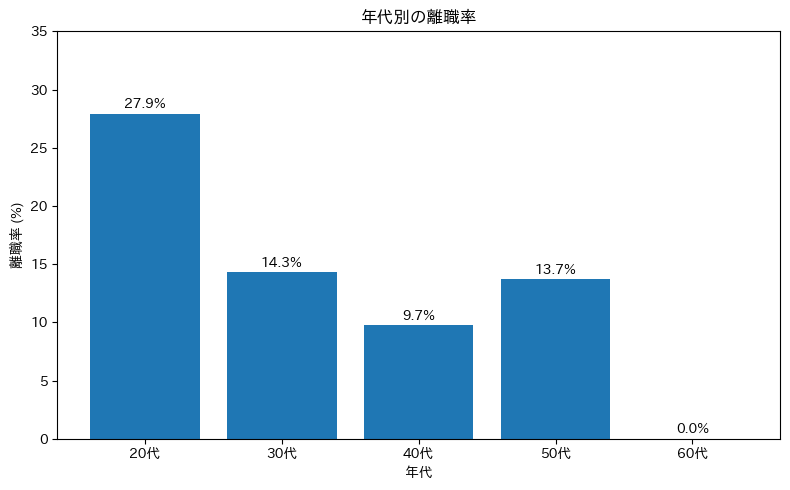

In [41]:
# 年代別の離職率を計算
age_attrition_rate = pd.crosstab(
    employee_df["AgeGroup"],
    employee_df["Attrition"],
    normalize="index"
)["Yes"] * 100

# グラフ作成
plt.figure(figsize=(8, 5))

plt.bar(
    age_attrition_rate.index.astype(str),
    age_attrition_rate.values
)

plt.title("年代別の離職率")
plt.xlabel("年代")
plt.ylabel("離職率 (%)")

# 各棒の上に数値を表示
for i, value in enumerate(age_attrition_rate.values):
   plt.text(i,
            value + 0.5,
            f"{value:.1f}%",
            ha="center")

plt.ylim(0, 35)
plt.tight_layout()

plt.savefig(
    "attrition_rate_by_age_group.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

20代の離職率は27.9%と年代別で最も高い結果となりました。

なお、60代は5人とサンプル数が少ないため、離職率0%については参考値として扱います。

### 10-2. JobLevel別の離職率

職位によって離職率にどの程度の違いがあるかを可視化します。

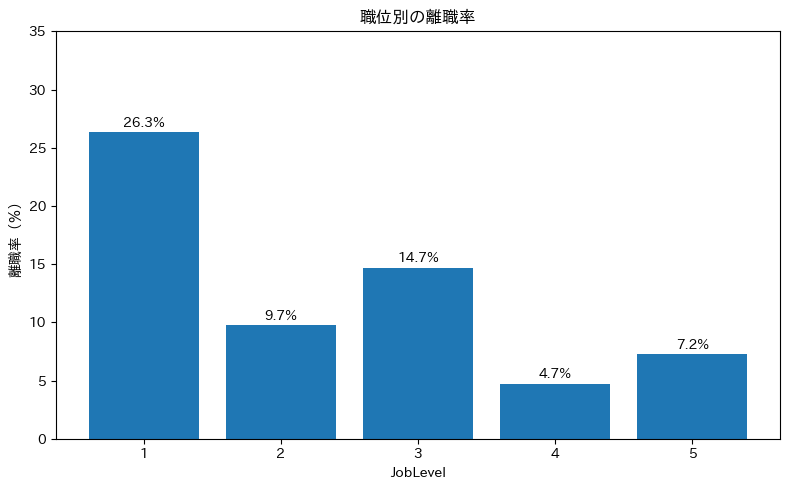

In [42]:
# 職位（JobLevel）別の離職率を計算
joblevel_attrition_rate = (
    pd.crosstab(
        employee_df["JobLevel"],
        employee_df["Attrition"],
        normalize="index"
    )["Yes"] * 100
)

# グラフ作成
plt.figure(figsize=(8, 5))

plt.bar(
    joblevel_attrition_rate.index.astype(str),
    joblevel_attrition_rate.values
)

plt.title("職位別の離職率")
plt.xlabel("JobLevel")
plt.ylabel("離職率（％）")

# 各棒の上に離職率を表示
for i, value in enumerate(joblevel_attrition_rate.values):
  plt.text(
      i,
      value + 0.5,
      f"{value:.1f}%",
      ha = "center"
  )

plt.ylim(0, 35)
plt.tight_layout()

plt.savefig(
    "attrition_rate_by_joblevel.png",
    dpi=300,
    bbox_inches="tight"
  )

plt.show()

JobLevel 1の離職率が26.3%と最も高い結果となりました。

ただし、JobLevel 2～5では離職率が職位の上昇に伴って一貫して低下しているわけではないため、
「JobLevelが低いほど離職率が高い」と単純に解釈することには注意が必要です。

### 10-3. JobRole別の離職率

職種別の離職率を比較し、離職率が高い職種を確認します。

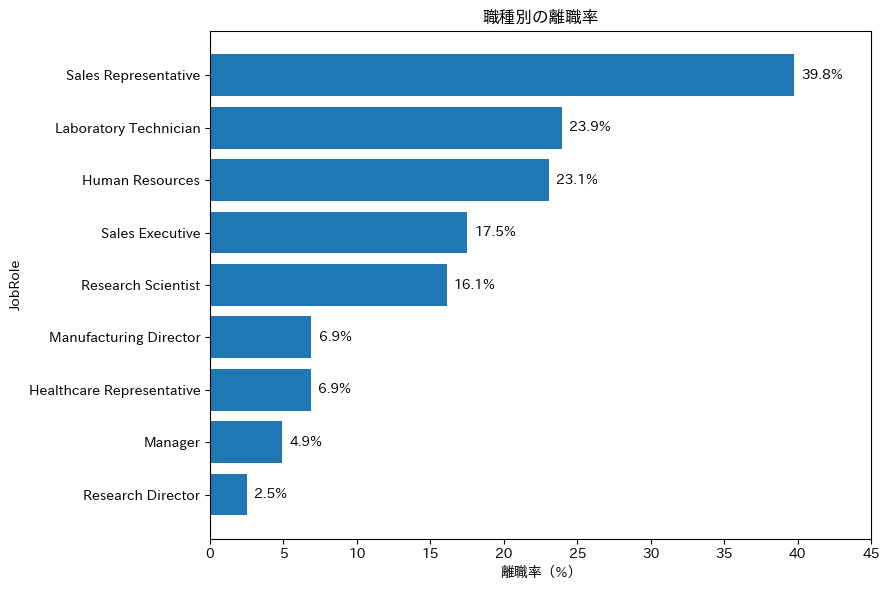

In [43]:
# 職種（JobRole）別の離職率を計算
jobrole_attrition_rate = (
    pd.crosstab(
        employee_df["JobRole"],
        employee_df["Attrition"],
        normalize="index"
    )["Yes"] * 100
)

# 離職率が高い順に並べる
jobrole_attrition_rate = jobrole_attrition_rate.sort_values(
    ascending=True
)

# グラフ作成
plt.figure(figsize=(9, 6))

plt.barh(
    jobrole_attrition_rate.index,
    jobrole_attrition_rate.values
)

plt.title("職種別の離職率")
plt.xlabel("離職率（%）")
plt.ylabel("JobRole")

# 各棒の右側に離職率を表示
for i, value in enumerate(jobrole_attrition_rate.values):
    plt.text(
        value + 0.5,
        i,
        f"{value:.1f}%",
        va="center"
    )

plt.xlim(0, 45)
plt.tight_layout()

plt.savefig(
    "attrition_rate_by_jobrole.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Sales Representativeの離職率が39.8%と職種別で最も高い結果となりました。

一方、Sales Representativeの約91.6%がJobLevel 1であるため、
職種だけでなくJobLevelの構成も考慮して解釈する必要があります。

### 10-4. JobSatisfaction × OverTime別の離職率

仕事満足度ごとに、残業の有無によって離職率がどのように異なるかを可視化します。

In [44]:
# 仕事満足度（JobSatisfaction） × 残業（OverTime）別の離職率を計算
jobsatisfaction_overtime_rate = (
    pd.crosstab(
        [employee_df["JobSatisfaction"], employee_df["OverTime"]],
        employee_df["Attrition"],
        normalize="index"
    )["Yes"] * 100
)

jobsatisfaction_overtime_rate

JobSatisfaction  OverTime
1                No          17.560976
                 Yes         35.714286
2                No           9.478673
                 Yes         37.681159
3                No           9.968847
                 Yes         33.884298
4                No           6.940063
                 Yes         21.126761
Name: Yes, dtype: float64

In [45]:
# グラフ用に表の形を変える
jobsatisfaction_overtime_plot = (
    jobsatisfaction_overtime_rate
    .unstack()
)

jobsatisfaction_overtime_plot

OverTime,No,Yes
JobSatisfaction,,
1,17.560976,35.714286
2,9.478673,37.681159
3,9.968847,33.884298
4,6.940063,21.126761


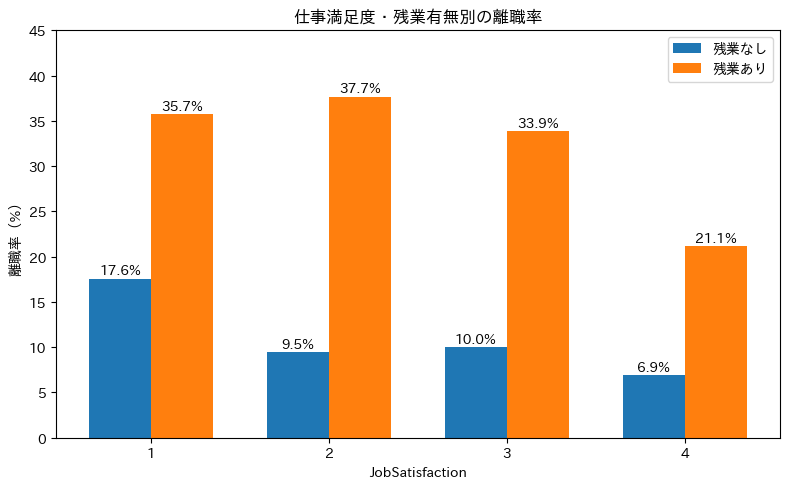

In [46]:
# グラフを作成

x = np.arange(len(jobsatisfaction_overtime_plot.index))
width = 0.35

plt.figure(figsize=(8, 5))

# 残業なし
plt.bar(
    x - width / 2,
    jobsatisfaction_overtime_plot["No"],
    width,
    label="残業なし"
)

# 残業あり
plt.bar(
    x + width / 2,
    jobsatisfaction_overtime_plot["Yes"],
    width,
    label="残業あり"
)

plt.title("仕事満足度・残業有無別の離職率")
plt.xlabel("JobSatisfaction")
plt.ylabel("離職率（%）")

# x軸のラベルを設定
plt.xticks(
    x,
    jobsatisfaction_overtime_plot.index
)

# 棒の上に離職率を表示
for i, value in enumerate(jobsatisfaction_overtime_plot["No"]):
  plt.text(
      x[i] - width / 2,
      value + 0.5,
      f"{value:.1f}%",
      ha="center"
  )

for i, value in enumerate(jobsatisfaction_overtime_plot["Yes"]):
  plt.text(
      x[i] + width / 2,
      value + 0.5,
      f"{value:.1f}%",
      ha="center"
  )

plt.ylim(0, 45)
plt.legend()
plt.tight_layout()

plt.savefig(
    "attrition_rate_by_jobsatisfaction_overtime.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

すべてのJobSatisfactionで、残業ありのグループは残業なしのグループより離職率が高い結果となりました。

仕事満足度が最も高いJobSatisfaction 4でも、
残業なしの離職率6.9%に対し、残業ありでは21.1%となっています。

この結果から、JobSatisfactionの水準にかかわらず、
OverTimeと離職の間に関連が見られました。

## 11. 考察・まとめ

今回の分析では、従業員の離職について年齢、勤続年数、職位（JobLevel）、月収（MonthlyIncome）、残業有無（OverTime）、職種（JobRole）、仕事満足度（JobSatisfaction）の観点から確認しました。

分析の結果、特に以下の特徴が確認されました。

### 主な分析結果

- 全体の離職率は16.1%でした。
- 年代別では20代の離職率が27.9%と最も高く、若年層の退職者は比較的勤続年数が短い傾向が見られました。
- JobLevel 1の離職率は26.3%で、退職者全体の約60.3%を占めていました。
- 退職者のMonthlyIncomeは在籍者より低い結果となりましたが、JobLevel 1に限定すると平均との差は大きく縮小しました。
- 残業ありの従業員の離職率は30.5%で、残業なしの10.4%と比較して約2.9倍でした。
- 20代 × JobLevel 1 × 残業ありのグループでは、67人中45人が退職し、離職率は67.2%でした。
- JobRole別ではSales Representativeの離職率が39.8%と最も高く、Sales Representativeの約91.6%がJobLevel 1でした。
- JobSatisfaction 1では離職率22.8%、4では11.3%でしたが、満足度が高くなるにつれて一貫して離職率が低下するわけではありませんでした。
- すべてのJobSatisfactionで、残業ありのグループは残業なしより離職率が高い結果となりました。

### 考察

#### 1. 若年層・JobLevel 1・残業ありの組み合わせに注目する必要がある

20代、JobLevel 1、残業ありの従業員では、それぞれ比較的高い離職率が確認されました。

特に、20代 × JobLevel 1 × 残業ありのグループでは離職率が67.2%となっており、
若手・低いJobLevel・残業という複数の特徴が重なる従業員について、
より詳しく状況を確認する必要があると考えられます。

#### 2. OverTimeは複数の分析で離職との関連が確認された

OverTimeは全体だけでなく、JobLevel別、JobRole別、JobSatisfaction別の分析でも、
多くのグループで残業ありの従業員の離職率が高い結果となりました。

そのため、今回確認した変数の中では、
OverTimeは離職との関連を継続的に確認できた項目の一つと考えられます。

#### 3. MonthlyIncomeやJobRoleは単独で解釈しないことが重要

退職者は在籍者よりMonthlyIncomeが低く、
Sales Representativeでは高い離職率が確認されました。

一方、退職者にはJobLevel 1が多く、
Sales Representativeの約91.6%もJobLevel 1でした。

このことから、MonthlyIncomeやJobRoleだけで離職を説明するのではなく、
JobLevelなど他の変数との関係も考慮する必要があります。

### 実務上の検討事項

今回の分析結果をもとに離職対策を検討する場合、
まずは残業が発生している背景を詳しく確認することが重要と考えます。

例えば、以下のような追加調査が考えられます。

- 部署や職種ごとの業務量・人員配置の確認
- 残業が多い従業員へのヒアリングや匿名アンケート
- 若手・JobLevel 1の従業員に対する定期的な1on1
- 教育体制や業務習熟までのサポート状況の確認
- 業務プロセスの見直しや人員配置の調整

特に若年層やJobLevel 1では勤続年数が短い退職者も多いため、
入社後の早い段階から定期的に状況を確認する仕組みも検討する方がよいと考えます。

### 分析上の注意点

本分析は各変数と離職との関連性を確認したものであり、
因果関係を示すものではありません。

例えば、残業ありの従業員で高い離職率が確認されましたが、
今回の分析だけから「残業が原因で離職した」と判断することはできません。

また、年齢、JobLevel、MonthlyIncome、JobRoleなど複数の変数が相互に関連している可能性があります。

より詳細に離職要因を検討するためには、
ロジスティック回帰などを用いた多変量分析や、
従業員アンケート・ヒアリングなどの定性的な情報を組み合わせることが考えられます。  

*ロジスティック回帰：  
複数の要因から「0か1か（起こるか起こらないか）」の二値の結果が起こる確率を予測・説明する統計的な分析手法です。